<a href="https://colab.research.google.com/github/smugAlex/BinarSys/blob/master/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Data and Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")
%matplotlib inline

In [2]:
from pylab import rcParams
rcParams['figure.figsize'] = 12, 8

In [3]:
import pandas as pd
import io
from google.colab import files

uploaded = files.upload()
data=pd.read_csv("data_3class.csv",index_col="t")
data.head()

Saving data_3class.csv to data_3class.csv


,x1,x2
t,,
0,34.623660,78.024693
0,30.286711,43.894998
0,35.847409,72.902198
2,60.182599,86.308552
1,79.032736,75.344376


In [4]:
feature = data[["x1", "x2"]].values
class_label = data.index.values



```
# This is formatted as code
```

### Visualize the Data

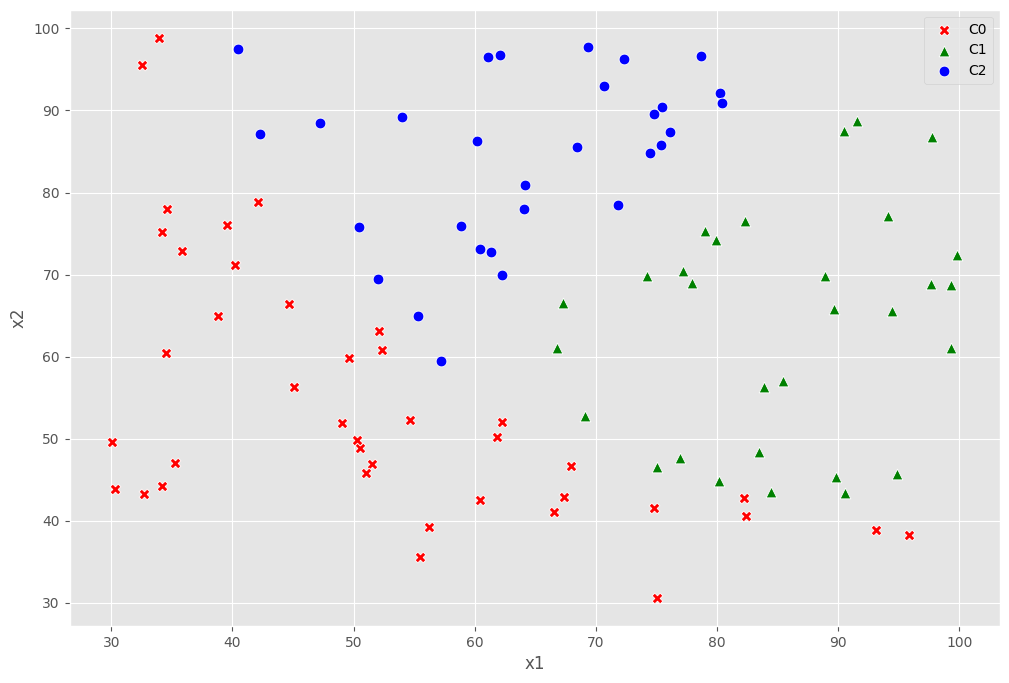

In [17]:

K = 3
mask = [(class_label == c) for c in range(K)]
markers = ["X", "^", "o"]
colors  = ["red", "green", "blue"]

for c in range(K):
    ax = sns.scatterplot(x=feature[mask[c], 0], y=feature[mask[c], 1],
                         marker=markers[c], color=colors[c], s=60)
ax.set(xlabel="x1", ylabel="x2")
ax.legend(["C0", "C1", "C2"])
plt.show();

### Define the Softmax Function

For $K$ classes, the model computes one score per class, $z_k = \mathbf{w}_k^T\mathbf{x}$, and softmax converts them into probabilities:

$$\hat{y}_k = \text{softmax}(\mathbf{W}^T\mathbf{x})_k = \frac{e^{\mathbf{w}_k^T\mathbf{x}}}{\sum_{j=0}^{K-1} e^{\mathbf{w}_j^T\mathbf{x}}}$$

This generalizes the sigmoid: for $K = 2$ it reduces to $\sigma(\mathbf{w}_1^T\mathbf{x})$.

Since softmax is invariant under a constant shift, $\text{softmax}(\mathbf{z} + c) = \text{softmax}(\mathbf{z})$, we subtract $\max_k z_k$ before exponentiating to avoid numerical overflow.

In [6]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

### Compute the Cost Function $J(\theta)$ and Gradient

In [7]:
def compute_cost(theta, x, y):
    m = len(y)
    y_pred = softmax(np.dot(x, theta))
    error = y * np.log(y_pred)
    cost = -1 / m * np.sum(error)
    gradient = 1 / m * np.dot(x.transpose(), (y_pred - y))
    return cost, gradient

### Cost and Gradient at Initialization

$\hat{y}_{nk} = \text{softmax}(\mathbf{W}^T\mathbf{x}_n)_k$ is the predicted probability that $\mathbf{x}_n$ belongs to $C_k$, and $y_{nk}$ is the one-hot label ($y_{nk} = 1$ if $\mathbf{x}_n$ belongs to $C_k$, else $0$).

The objective is to minimize the negative log-likelihood (multi-class cross-entropy):

$$E(\mathbf{W}) = -\frac{1}{N}\sum_{n=1}^{N}\sum_{k=0}^{K-1} y_{nk}\ln\hat{y}_{nk}$$

with gradient

$$\nabla_{\mathbf{w}_k}E(\mathbf{W}) = \frac{1}{N}\sum_{n=1}^{N}(\hat{y}_{nk} - y_{nk})\,\mathbf{x}_n$$

In matrix form this is $\frac{1}{N}\mathbf{X}^T(\hat{\mathbf{Y}} - \mathbf{Y})$, which has the same form as the binary case — so the gradient line in the code is unchanged.

### Gradient Descent

In [8]:
mean_scores = np.mean(feature, axis=0)
std_scores = np.std(feature, axis=0)
scores = (feature - mean_scores) / std_scores #standardization

rows = feature.shape[0]
cols = feature.shape[1]

X = np.append(np.ones((rows, 1)), scores, axis=1) #include intercept
Y = np.eye(K)[class_label]
theta_init = np.zeros((cols + 1, K))
cost, gradient = compute_cost(theta_init, X, Y)

print("Cost at initialization", cost)
print("Gradient at initialization:", gradient)

Cost at initialization 1.0986122886681098
Gradient at initialization: [[-0.06666667  0.03333333  0.03333333]
 [ 0.28122914 -0.30581688  0.02458774]
 [ 0.25098615  0.043352   -0.29433815]]


Minimize the cost function $J(\boldsymbol \theta)$ by updating the below equation and repeat until convergence:
$\boldsymbol \theta_{j+1} := \boldsymbol \theta_j - \alpha \frac{\partial J(\boldsymbol \theta)}{\partial \boldsymbol \theta_j}$.

See https://en.wikipedia.org/wiki/Gradient_descent.

In [9]:
def gradient_descent(x, y, theta, alpha, iterations):
    theta = theta.copy()
    costs = []
    for i in range(iterations):
        cost, gradient = compute_cost(theta, x, y)
        theta = theta - alpha * gradient
        costs.append(cost)
    return theta, costs

In [10]:
theta, costs = gradient_descent(X, Y, theta_init, 1, 2000)
print(theta)

[[-0.11327884 -0.15426952  0.26754837]
 [-2.66509433  2.43281844  0.23227589]
 [-2.30880724  0.4119649   1.89684233]]


In [11]:
print("Theta after running gradient descent:", theta)
print("Resulting cost:", costs[-1])

Theta after running gradient descent: [[-0.11327884 -0.15426952  0.26754837]
 [-2.66509433  2.43281844  0.23227589]
 [-2.30880724  0.4119649   1.89684233]]
Resulting cost: 0.4026190494145715


Plot $J(\boldsymbol \theta)$ against the number of iterations of gradient descent:

### Plotting the Convergence of $J(\boldsymbol \theta)$

<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_926/3802177551.py:3: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel("$J(\Theta)$")


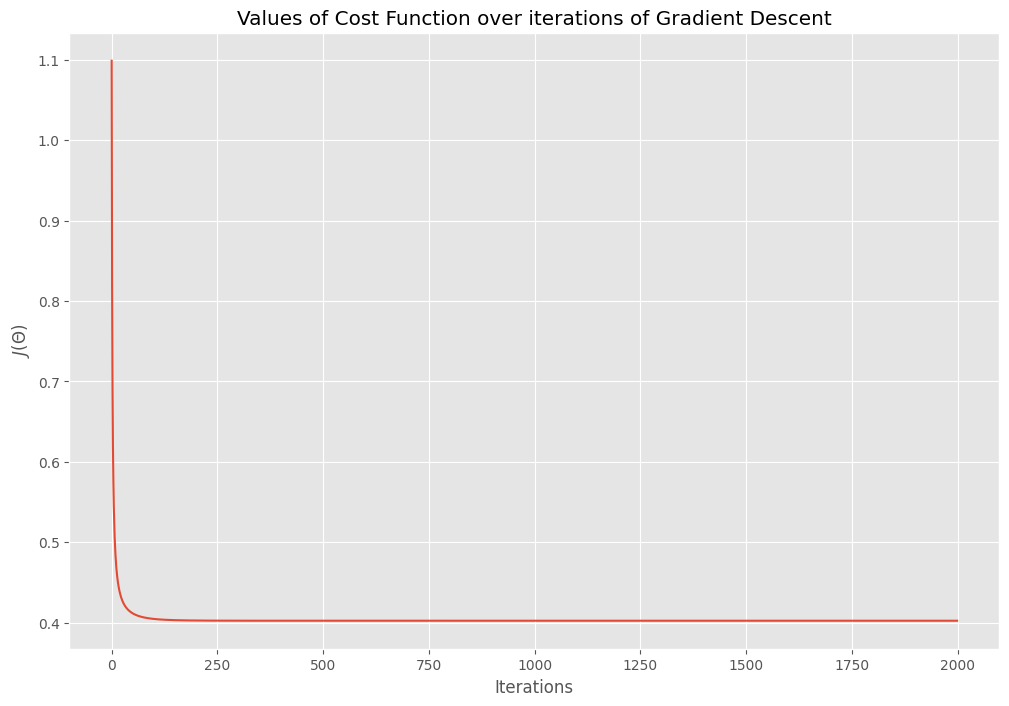

In [12]:
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("$J(\Theta)$")
plt.title("Values of Cost Function over iterations of Gradient Descent");



```
# 코드로 형식 지정됨
```

### Plotting the decision boundary

### Decision Boundaries

The model predicts the class with the highest score:

$$\hat{t} = \arg\max_k \; \mathbf{w}_k^T \mathbf{x}$$

Classes $i$ and $j$ are tied where their scores are equal, so the boundary between them is

$$\mathbf{w}_i^T\mathbf{x} = \mathbf{w}_j^T\mathbf{x} \quad \Longleftrightarrow \quad (\mathbf{w}_i - \mathbf{w}_j)^T\mathbf{x} = 0$$

which is a straight line. For $K = 3$ there are three such lines, and they all intersect at the point where all three scores are equal (where each class has probability $1/3$). A single boundary line as in the binary case no longer suffices, so we visualize the decision regions instead.

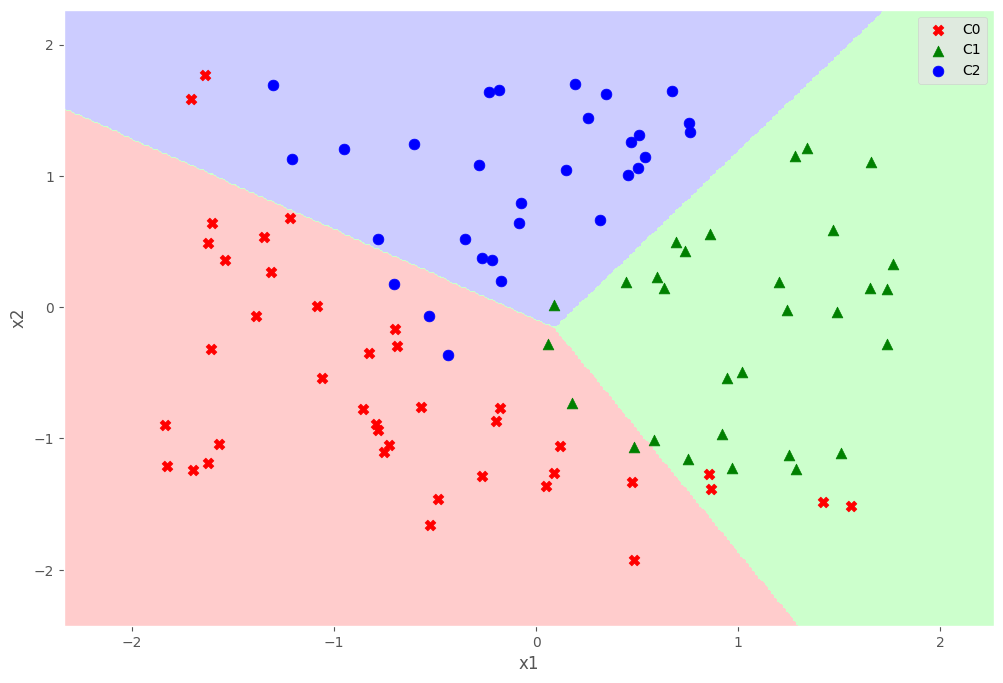

In [13]:
x1_range = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
x2_range = np.linspace(X[:, 2].min() - 0.5, X[:, 2].max() + 0.5, 300)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

grid = np.c_[np.ones(xx1.size), xx1.ravel(), xx2.ravel()]
Z = np.argmax(grid.dot(theta), axis=1).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=["#ffcccc", "#ccffcc", "#ccccff"])

for c in range(K):
    plt.scatter(X[mask[c], 1], X[mask[c], 2],
                marker=markers[c], color=colors[c], s=60, label=f"C{c}")

plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.show();

### Predictions using the optimized $\theta$ values

In [14]:
def predict(theta, x):
    return np.argmax(x.dot(theta), axis=1)

p = predict(theta, X)
print(p)


[0 0 0 2 1 0 2 0 2 1 1 0 1 2 0 2 0 0 2 1 0 1 0 0 1 2 1 1 0 0 2 1 0 0 0 0 2
 2 0 0 1 0 1 1 0 0 1 1 2 1 1 1 1 0 0 0 1 2 1 2 2 0 0 0 0 0 2 0 2 0 0 2 2 2
 2 1 2 2 0 1 1 1 2 0 2 2 0 2 2 0 1 1 0 2 1 1 2 1 0 2]


In [15]:
print("Training Accuracy:", np.mean(p == class_label) * 100, "%")

Training Accuracy: 87.0 %


In [16]:
test = np.array([50, 79])
test = (test - mean_scores) / std_scores      # same transform as training
test = np.append(np.ones(1), test)            # intercept

probability = softmax(test.reshape(1, -1).dot(theta))[0]

for c in range(K):
    print(f"P(C{c} | x1=50, x2=79) = {np.round(probability[c], 4)}")
print("Predicted class:", np.argmax(probability))
print("Sum of probabilities:", np.round(probability.sum(), 6))

P(C0 | x1=50, x2=79) = 0.2719
P(C1 | x1=50, x2=79) = 0.0278
P(C2 | x1=50, x2=79) = 0.7003
Predicted class: 2
Sum of probabilities: 1.0
